In [1]:
# https://huggingface.co/microsoft/Florence-2-large/blob/main/sample_inference.ipynb
from transformers import AutoProcessor, AutoModelForCausalLM  
from PIL import Image
import requests
import copy
%matplotlib inline  


/home/ubuntu/miniconda3/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = 'microsoft/Florence-2-large'
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True).eval().cuda()
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

/home/ubuntu/miniconda3/envs/llava/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/ubuntu/miniconda3/envs/llava/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/ubuntu/miniconda3/envs/llava/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_d

In [3]:
model.save_pretrained('microsoft_Florence-2-large_local')

Removed shared tensor {'language_model.model.decoder.embed_tokens.weight', 'language_model.model.encoder.embed_tokens.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


: 

In [3]:
def run_example(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    generated_ids = model.generate(
      input_ids=inputs["input_ids"].cuda(),
      pixel_values=inputs["pixel_values"].cuda(),
      max_new_tokens=1024,
      early_stopping=False,
      do_sample=False,
      num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )

    return parsed_answer

In [20]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg?download=true"
# image = Image.open(requests.get(url, stream=True).raw)
image = Image.open("/home/ubuntu/Multimodal-Uncertainty-Quantification/models/ml-ferret/ferret/serve/examples/ferret.jpg")


import pandas as pd
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets/MMT-Bench/MMT-Bench_VAL.tsv'
df = pd.read_csv(path, sep='\t')

In [21]:
df.columns

Index(['index', 'question', 'answer', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H',
       'I', 'image', 'category', 'l2-category', 'split'],
      dtype='object')

In [23]:
df_hal = df[df['category'].str.contains('hallucination', na=False)]


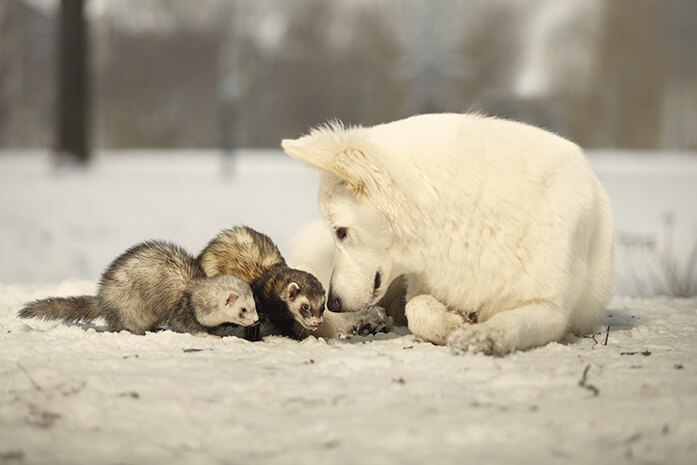

In [13]:
image

### Captioning

In [14]:
task_prompt = '<CAPTION>'
run_example(task_prompt)

{'<CAPTION>': '\nA white wolf playing with two ferrets in the snow.\n'}

In [15]:
task_prompt = '<DETAILED_CAPTION>'
run_example(task_prompt)

{'<DETAILED_CAPTION>': '\nThe image shows a white polar bear playing with two ferrets in the snow. The background is blurred, giving the focus to the polar bear and the ferrets.\n'}

In [16]:
task_prompt = '<MORE_DETAILED_CAPTION>'
run_example(task_prompt)

{'<MORE_DETAILED_CAPTION>': '\nThe image shows a large white polar bear lying on a snow-covered ground. The bear is facing towards the right side of the image and appears to be sniffing the ground. In front of the bear, there is a small ferret lying on its side. The ferret is brown and black in color and is looking towards the bear. The background is blurred, but it seems to be a snowy landscape with trees and bushes.\n'}

### Object Detection

In [17]:
task_prompt = '<OD>'
results = run_example(task_prompt)

In [18]:
import matplotlib.pyplot as plt  
import matplotlib.patches as patches  
def plot_bbox(image, data):
   # Create a figure and axes  
    fig, ax = plt.subplots()  
      
    # Display the image  
    ax.imshow(image)  
      
    # Plot each bounding box  
    for bbox, label in zip(data['bboxes'], data['labels']):  
        # Unpack the bounding box coordinates  
        x1, y1, x2, y2 = bbox  
        # Create a Rectangle patch  
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')  
        # Add the rectangle to the Axes  
        ax.add_patch(rect)  
        # Annotate the label  
        plt.text(x1, y1, label, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))  
      
    # Remove the axis ticks and labels  
    ax.axis('off')  
      
    # Show the plot  
    plt.show()  

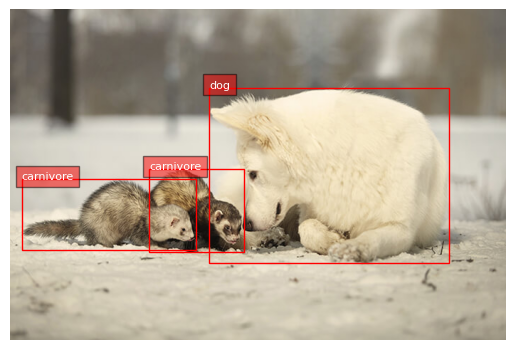

In [19]:
plot_bbox(image, results['<OD>'])
